In [1]:
# import packages

import xarray as xr
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import t
import pandas as pd

## dask

In [2]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=1,
        memory='10GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=10GB',
        account='XX',
        walltime='02:00:00')
        #interface='ib0',)

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [3]:
cluster, client = get_ClusterClient()
cluster.adapt(minimum=0, maximum=10)

In [4]:
cluster

Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.68:41799,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [30]:
cluster.close()
client.close()

NameError: name 'cluster' is not defined

## load data

In [14]:
press_sequential = xr.open_dataset('press_sequential.nc')
u10_sequential = xr.open_dataset('u10_sequential.nc')
u850_sequential = xr.open_dataset('u850_sequential.nc')
meridional_stress_sequential = xr.open_dataset('meridional_stress_sequential.nc')
zonal_stress_sequential = xr.open_dataset('zonal_stress_sequential.nc')
precip_sequential = xr.open_dataset('precip_sequential.nc')
geo850_sequential = xr.open_dataset('geo850_sequential.nc')
geo500_sequential = xr.open_dataset('geo500_sequential.nc')
geo200_sequential = xr.open_dataset('geo200_sequential.nc')
soi = xr.open_dataset('soi_index.nc')
nino34_sm = xr.open_dataset('nino34_spatialmean.nc')
nino4_sm = xr.open_dataset('nino4_spatialmean.nc')
nino3_sm = xr.open_dataset('nino3_spatialmean.nc')
nino12_sm = xr.open_dataset('nino12_spatialmean.nc')
latent_representations = xr.open_dataset('latent_representations_zmean.nc')
oni_e3sm = xr.open_dataset('oni_e3sm_0502.nc')
sst_yindx = np.load('sst_yindx.npy')
sst_xindx = np.load('sst_xindx.npy')
peak_lon_nino = np.load('peak_lon_nino.npy')
peak_lon_nina = np.load('peak_lon_nina.npy')
eli = xr.open_dataset('eli_0315.nc')
pdo = xr.open_dataset('pdo.nc')
tpdv = xr.open_dataset('tpdv_v1.nc')

In [15]:
pdo

<xarray.Dataset> Size: 144kB
Dimensions:  (time: 6000)
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    mode     int64 8B ...
    month    (time) int64 48kB ...
Data variables:
    pcs      (time) float64 48kB ...

In [16]:
tpdv

<xarray.Dataset> Size: 144kB
Dimensions:                                    (time: 6000)
Coordinates:
  * time                                       (time) object 48kB 0001-01-01 ...
    month                                      (time) int64 48kB ...
Data variables:
    timeMonthly_avg_activeTracers_temperature  (time) float64 48kB ...

In [17]:
sequential_input_ohc_train = xr.load_dataarray('ohc700_train_robustscaler.nc')
sequential_input_ohc_test = xr.load_dataarray('ohc700_test_robustscaler.nc')

sequential_input_olr_train = xr.load_dataarray('olr_train_robustscaler.nc')
sequential_input_olr_test = xr.load_dataarray('olr_test_robustscaler.nc')

sequential_input_sst_train = xr.load_dataarray('sst_train_robustscaler.nc')
sequential_input_sst_test = xr.load_dataarray('sst_test_robustscaler.nc')

ohc_combined = xr.concat([sequential_input_ohc_train, sequential_input_ohc_test], dim='time')
olr_combined = xr.concat([sequential_input_olr_train, sequential_input_olr_test], dim='time')
sst_combined = xr.concat([sequential_input_sst_train, sequential_input_sst_test], dim='time')

# use sort by for sequential data along time dimension
ohc_sequential = ohc_combined.sortby('time')
olr_sequential = olr_combined.sortby('time')
sst_sequential = sst_combined.sortby('time')

## spatial means

In [18]:
sst_sm = sst_sequential.mean('newdim')
ohc_sm = ohc_sequential.mean('newdim')
olr_sm = olr_sequential.mean('newdim')
press_sm = press_sequential['PS'].mean('space')
u10_sm = u10_sequential['U10'].mean('space')
u850_sm = u850_sequential['U'].mean('space')
meridional_stress_sm = meridional_stress_sequential['TAUY'].mean('space')
zonal_stress_sm = zonal_stress_sequential['TAUX'].mean('space')
precip_sm = precip_sequential['TMQ'].mean('space')
geo850_sm = geo850_sequential['Z3'].mean('space')
geo500_sm = geo500_sequential['Z3'].mean('space')
geo200_sm = geo200_sequential['Z3'].mean('space')

In [19]:
anom34_sm = nino34_sm['timeMonthly_avg_activeTracers_temperature'].values
anom4_sm = nino4_sm['timeMonthly_avg_activeTracers_temperature'].values
anom3_sm = nino3_sm['timeMonthly_avg_activeTracers_temperature'].values
anom12_sm = nino12_sm['timeMonthly_avg_activeTracers_temperature'].values

In [20]:
soi = soi['PS'].values
eli = eli['ELI'].values
pdo = pdo['pcs'].values
tpdv = tpdv['timeMonthly_avg_activeTracers_temperature'].values

In [21]:
tpdv

array([-0.0599848 , -0.05810128, -0.05766161, ...,  0.08350499,
        0.08677316,  0.089512  ])

In [22]:
print(sst_sm.shape,
      anom34_sm.shape,
      anom4_sm.shape,
      anom3_sm.shape,
      anom12_sm.shape,
      soi.shape,
      ohc_sm.shape,
      olr_sm.shape,
      press_sm.shape,
      u10_sm.shape,
      u850_sm.shape,
      meridional_stress_sm.shape,
      zonal_stress_sm.shape,
      precip_sm.shape,
      geo850_sm.shape,
      geo500_sm.shape,
      geo200_sm.shape,
      soi.shape,
      eli.shape,
      pdo.shape,
      tpdv.shape
     )

(6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,) (6000,)


In [23]:
latent_representations = latent_representations['z_mean'].values

In [24]:
latent_representations.shape

(6000, 20)

## compute correlations

In [25]:
def effective_dof(x, y):
    """Estimate effective DOF accounting for lag-1 autocorrelation."""
    n = len(x)
    r1x = np.corrcoef(x[:-1], x[1:])[0, 1]
    r1y = np.corrcoef(y[:-1], y[1:])[0, 1]
    n_eff = n * (1 - r1x * r1y) / (1 + r1x * r1y)
    return max(n_eff, 3)  # floor at 3 to avoid degenerate cases

def correlate_latent_with_indices(latent, indices_dict):
    latent = np.asarray(latent)
    n_time, n_latent = latent.shape
    latent_centered = latent - latent.mean(axis=0)

    corr_dict = {}
    pval_dict = {}
    dof_dict  = {}

    for name, idx in indices_dict.items():
        idx = np.asarray(idx).squeeze()
        idx_centered = idx - idx.mean()

        # Pearson r (vectorized across latent dims)
        r = np.sum(latent_centered * idx_centered[:, None], axis=0) / (
            np.sqrt(np.sum(latent_centered**2, axis=0)) *
            np.sqrt(np.sum(idx_centered**2))
        )

        # Effective DOF per latent dimension
        dof_array = np.array([
            effective_dof(latent_centered[:, i], idx_centered)
            for i in range(n_latent)
        ])

        tstat = r * np.sqrt(dof_array / (1.0 - np.clip(r**2, 0, 1 - 1e-10)))
        pval  = 2 * (1 - t.cdf(np.abs(tstat), df=dof_array))

        corr_dict[name] = r
        pval_dict[name] = pval
        dof_dict[name]  = dof_array

    return corr_dict, pval_dict, dof_dict


indices = {
    "Sea Surface Temperature":          np.asarray(sst_sm.values).squeeze(),
    "SST: Niño 3.4":                   np.asarray(anom34_sm).squeeze(),
    "SST: Niño 3":                     np.asarray(anom3_sm).squeeze(),
    "SST: Niño 4":                     np.asarray(anom4_sm).squeeze(),
    "SST: Niño 1+2":                   np.asarray(anom12_sm).squeeze(),
    "ENSO Longitude Index (ELI)":      np.asarray(eli).squeeze(),
    "Pacific Decadal Oscillation":     np.asarray(pdo).squeeze(),
    "Tropical Pacific Decadal Variability": np.asarray(tpdv).squeeze(),
    "Surface Pressure":                np.asarray(press_sm.values).squeeze(),
    "Southern Oscillation Index":      np.asarray(soi).squeeze(),
    "Ocean Heat Content":              np.asarray(ohc_sm.values).squeeze(),
    "Outgoing Longwave Radiation":     np.asarray(olr_sm.values).squeeze(),
    "850hPa Zonal Wind":               np.asarray(u850_sm.values).squeeze(),
    "10m Wind Speed":                  np.asarray(u10_sm.values).squeeze(),
    "Meridional Surface Stress":       np.asarray(meridional_stress_sm.values).squeeze(),
    "Zonal Surface Stress":            np.asarray(zonal_stress_sm.values).squeeze(),
    "Total Precipitable Water":        np.asarray(precip_sm.values).squeeze(),
    "850 hPa Geopotential Height":     np.asarray(geo850_sm.values).squeeze(),
    "500 hPa Geopotential Height":     np.asarray(geo500_sm.values).squeeze(),
    "200 hPa Geopotential Height":     np.asarray(geo200_sm.values).squeeze(),
}

corr_dict, pval_dict, dof_dict = correlate_latent_with_indices(latent_representations, indices)

# build DataFrames
ld_labels = [f"LD{i}" for i in range(latent_representations.shape[1])]

signed_corr_df = pd.DataFrame(corr_dict, index=ld_labels).T
abs_corr_df    = pd.DataFrame({k: np.abs(v) for k, v in corr_dict.items()}, index=ld_labels).T
pval_df        = pd.DataFrame(pval_dict, index=ld_labels).T
dof_df         = pd.DataFrame(dof_dict, index=ld_labels).T

print("Correlation shape:", signed_corr_df.shape)
print("P-value shape:", pval_df.shape)
print("\nEffective DOF (first index, all LDs):")
print(dof_df.iloc[0].values.astype(int))  # sanity check - should be << 6000

Correlation shape: (20, 20)
P-value shape: (20, 20)

Effective DOF (first index, all LDs):
[ 784  747 2058 1444 2991 1128 1814 1268 1549 1476 1561 1051 1737 1318
 1175 1338 1037 1679 1909 1044]


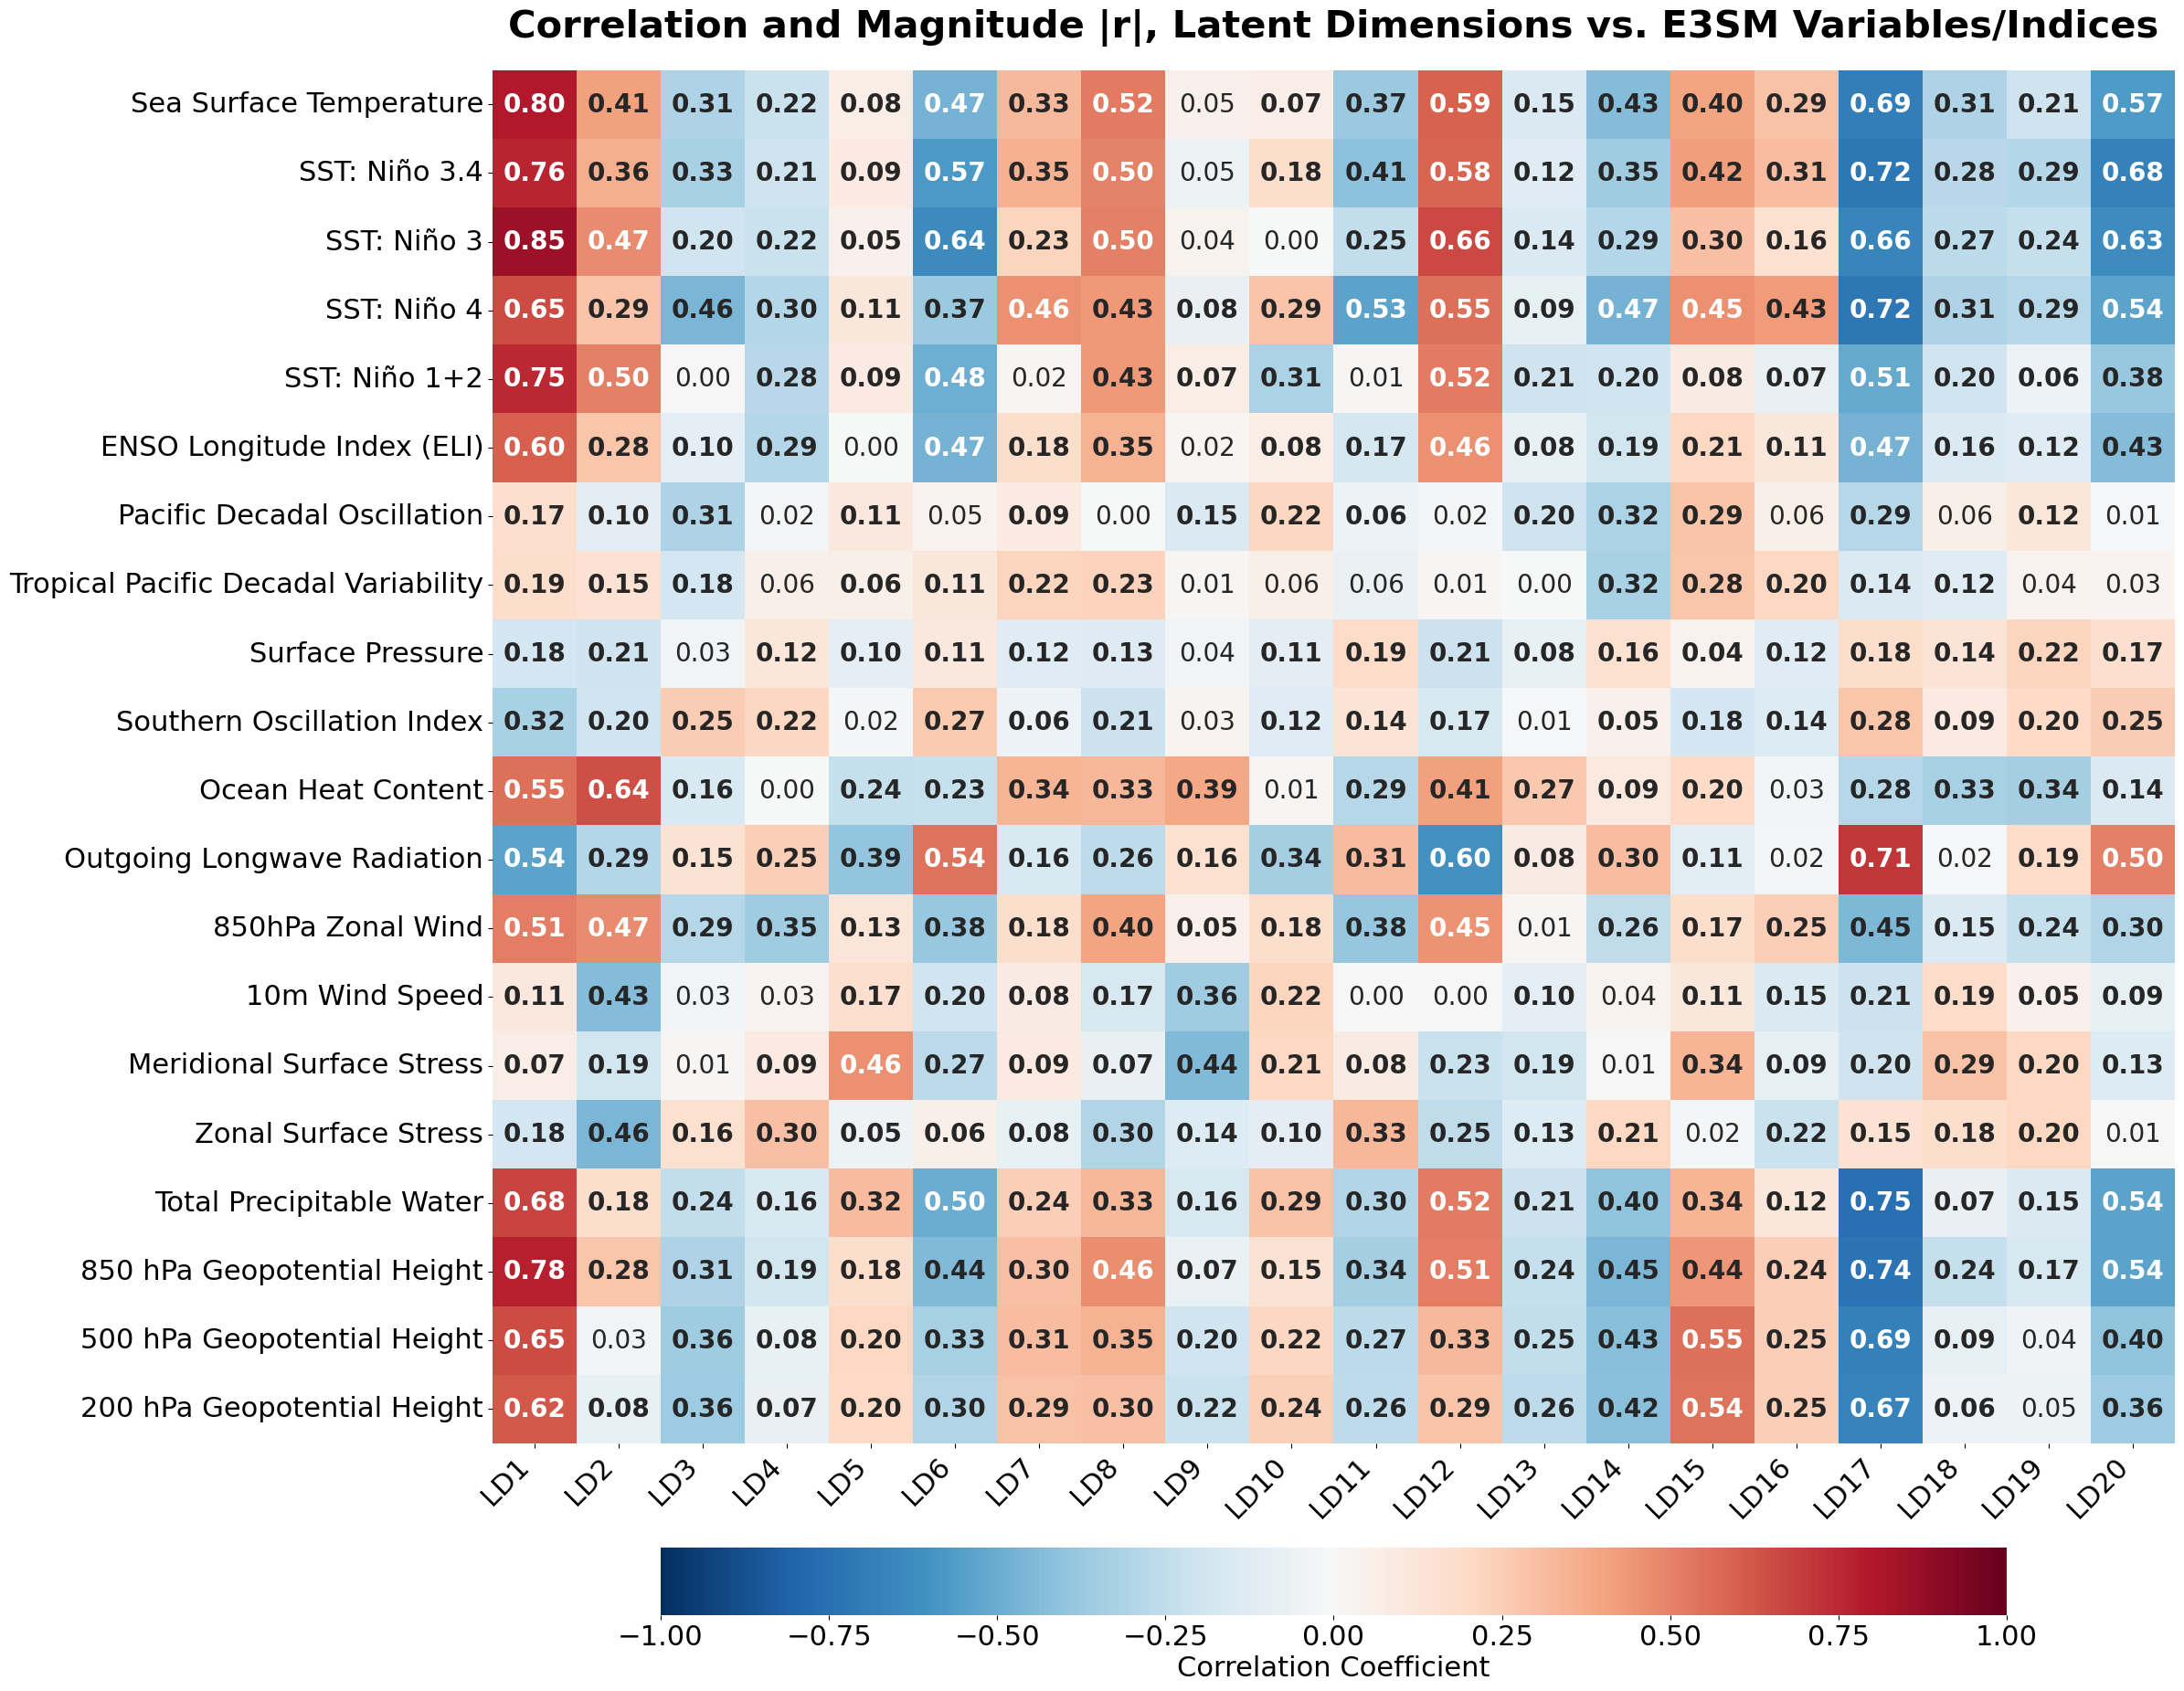

In [29]:
alpha = 0.01

plt.figure(figsize=(24, 20))
ax = sns.heatmap(
    signed_corr_df,
    annot=abs_corr_df.values,              # annotate magnitude from abs_corr_df
    fmt=".2f",
    cmap="RdBu_r",
    center=0.0,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 20},
    cbar_kws={
        "orientation": "horizontal",
        "label": "Correlation Coefficient",
        "pad": 0.06,
        "shrink": 0.8,
        "extend": "neither"
    }
)

for text in ax.texts:
    col = int(text.get_position()[0] - 0.5)
    row = int(text.get_position()[1] - 0.5)
    if pval_df.iloc[row, col] < alpha:
        text.set_fontweight("bold")

cbar = ax.collections[0].colorbar
cbar.ax.xaxis.label.set_size(22)
cbar.ax.tick_params(labelsize=22)

ax.set_xticklabels([f'LD{i}' for i in range(1, len(signed_corr_df.columns) + 1)], 
                   rotation=45, ha="right", fontsize=22)

plt.xticks(rotation=45, ha="right", fontsize=22)
plt.yticks(fontsize=22)
plt.title(
    "Correlation and Magnitude |r|, Latent Dimensions vs. E3SM Variables/Indices",
    fontweight="bold",
    fontsize=30,
    pad=26
)
plt.tight_layout()
#plt.savefig("corrmap_0315.pdf", bbox_inches='tight')
plt.show()